In [1]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 874.1/874.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [2]:
# Desativando os avisos no notebook para manter células de saída limpas
import warnings
warnings.filterwarnings('ignore')

# Importação das bibliotecas necessárias
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import cv2
import yaml
from PIL import Image
from ultralytics import YOLO
from IPython.display import Video

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Programa k/Road Box')
HOME = os.getcwd()

Mounted at /content/drive


In [4]:
# Configurando a aparência visual dos gráficos do Seaborn
sns.set(rc={'axes.facecolor': '#eae8fa'}, style='darkgrid')

# Carregando um modelo YOLOv8n pré-treinado do Ultralytics
model = YOLO('yolov8n.pt')

# Detecção placas

## Treinamento

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="uSQCZ7eejOFwZdKg9IV8")
project = rf.workspace("lprtesting-ivtrm").project("lpr-testing")
version = project.version(1)
dataset = version.download("yolov8-obb")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
# Treine o modelo em nosso conjunto de dados personalizado
results = model.train(
    data=f'{dataset.location}/data.yaml',     # Caminho para o arquivo de configuração do conjunto de dados
    epochs=50,                                            # Número de épocas para treinar
    imgsz=640,                                            # Tamanho das imagens de entrada como número inteiro
    device=0,                                             # Dispositivo para execução, ou seja, dispositivo cuda = 0
    patience=50,                                          # Épocas para esperar por nenhuma melhoria observável para a interrupção antecipada do treinamentog
    batch=16,                                             # Número de imagens por lote
    optimizer='auto',                                     # Otimizador a ser usado, escolhas=[SGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp, auto]
    lr0=0.0001,                                           # Taxa de aprendizagem inicial
    lrf=0.1,                                              # Taxa final de aprendizagem (lr0 * lrf)
    dropout=0.1,                                          # Use regularização de abandono
    seed=0,                                               # Semente aleatória para reprodutibilidade
    name='detect-car-license'
)

Ultralytics YOLOv8.2.96 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/Programa k/RoadBox IA/LPR-testing-1/data.yaml, epochs=50, time=None, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=detect-car-license, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.1, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_

train: Scanning /content/drive/MyDrive/Programa k/RoadBox IA/LPR-testing-1/train/labels... 3437 images, 0 backgrounds, 1473 corrupt: 100%|██████████| 3437/3437 [01:07<00:00, 50.77it/s] 

train: WARNING ⚠️ /content/drive/MyDrive/Programa k/RoadBox IA/LPR-testing-1/train/images/006a4642-7d52-4eef-a5ed-d13bbc1e9b81_jpg.rf.de1b5a60a0fb67bb118a7e87b103844e.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.3677      1.2163]
train: WARNING ⚠️ /content/drive/MyDrive/Programa k/RoadBox IA/LPR-testing-1/train/images/0077dffb-63ac-4711-a064-ce45c93a66b9_jpg.rf.1e714e8bc02afe034c65f64d1d77e8a5.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.2602]
train: WARNING ⚠️ /content/drive/MyDrive/Programa k/RoadBox IA/LPR-testing-1/train/images/00a170f0-eeb2-4ea9-8ad8-4c86feb3d89e_jpg.rf.04528e5fb3ca70db5e64128f9e82d560.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.1537]
train: WARNING ⚠️ /content/drive/MyDrive/Programa k/RoadBox IA/LPR-testing-1/train/images/00f87d4e-1532-462b-8277-39778481ecd3-Copia_jpg.rf.36992770bec0a19dbee98ebc75345778.jpg: ignoring corrupt image/label: 

train: New cache created: /content/drive/MyDrive/Programa k/RoadBox IA/LPR-testing-1/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/drive/MyDrive/Programa k/RoadBox IA/LPR-testing-1/valid/labels... 982 images, 0 backgrounds, 406 corrupt: 100%|██████████| 982/982 [00:15<00:00, 61.93it/s] 

...

      50/50      2.15G     0.4742     0.2996     0.8741         12        640: 100%|██████████| 123/123 [00:52<00:00,  2.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:07<00:00,  2.25it/s]

                   all        576        578      0.988      0.977      0.994      0.876



50 epochs completed in 0.907 hours.
Optimizer stripped from runs/detect/detect-car-license/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/detect-car-license/weights/best.pt, 6.3MB

Validating runs/detect/detect-car-license/weights/best.pt...
Ultralytics YOLOv8.2.96 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:13<00:00,  1.32it/s]


                   all        576        578      0.988       0.97      0.992       0.88
                     0        212        212      0.981      0.979      0.994      0.889
                     1        364        366      0.994      0.961      0.991       0.87
Speed: 0.3ms preprocess, 2.7ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to runs/detect/detect-car-license


## Testes e validação

In [5]:
yolo_plate = YOLO('runs/detect/detect-car-license/weights/best.pt')

In [6]:
# Define uma função para traçar curvas de aprendizado para valores de perda
def plot_learning_curve(df, train_loss_col, val_loss_col, title):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df, x='epoch', y=train_loss_col, label='Train Loss', color='#141140', linestyle='-', linewidth=2)
    sns.lineplot(data=df, x='epoch', y=val_loss_col, label='Validation Loss', color='orangered', linestyle='--', linewidth=2)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

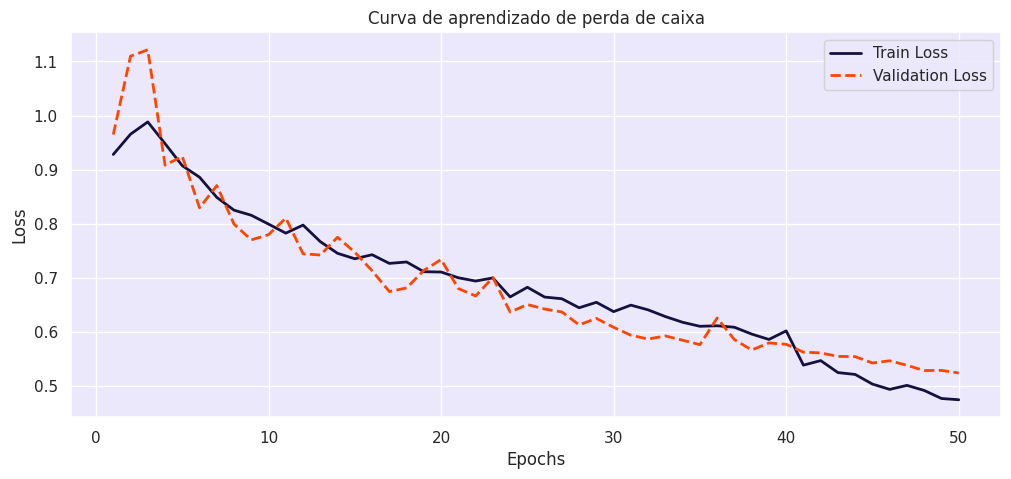

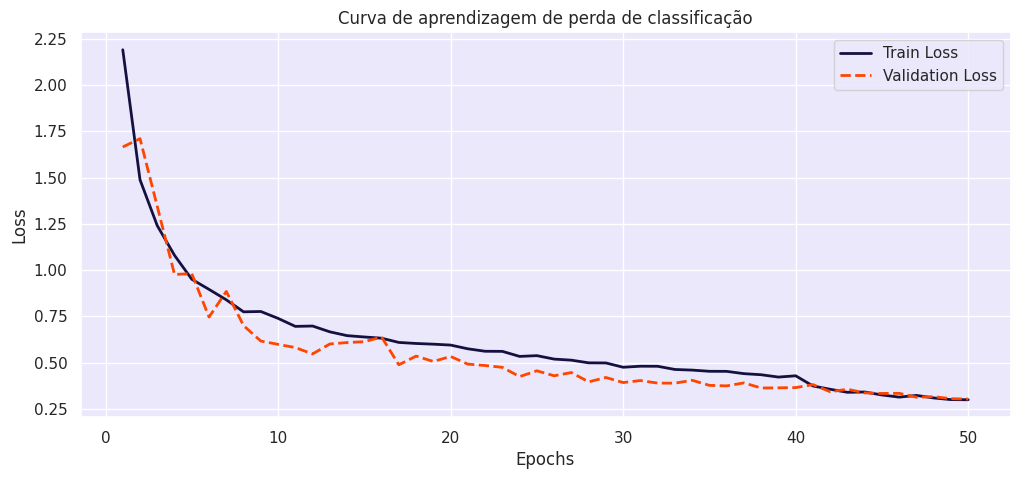

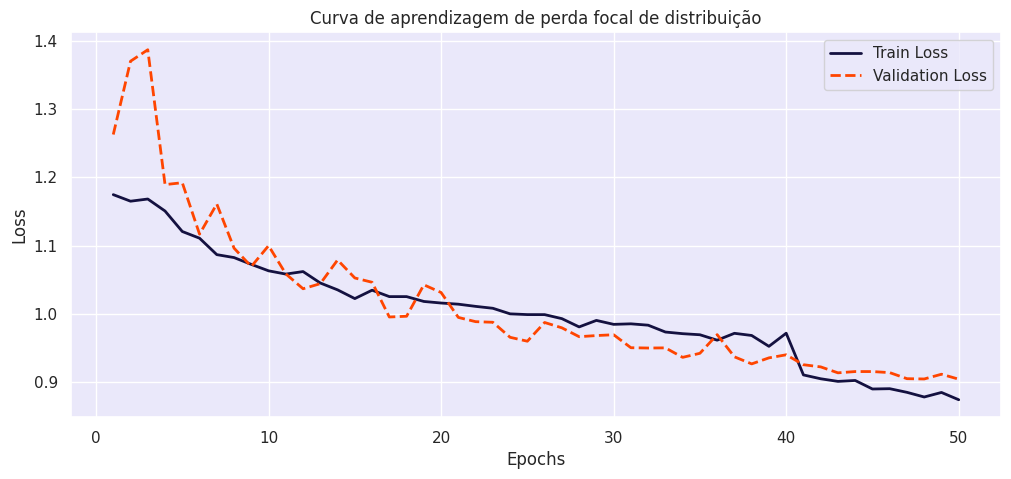

In [ ]:
# Crie o caminho completo do arquivo para 'results.csv' usando o caminho do diretório e o nome do arquivo
results_csv_path = os.path.join('runs/detect/detect-car-license', 'results.csv')

# Carregue o arquivo CSV do caminho construído em um DataFrame do pandas
df = pd.read_csv(results_csv_path)

# Remova qualquer espaço em branco inicial dos nomes das colunas
df.columns = df.columns.str.strip()

# lote as curvas de aprendizado para cada perda
plot_learning_curve(df, 'train/box_loss', 'val/box_loss', 'Curva de aprendizado de perda de caixa')
plot_learning_curve(df, 'train/cls_loss', 'val/cls_loss', 'Curva de aprendizagem de perda de classificação')
plot_learning_curve(df, 'train/dfl_loss', 'val/dfl_loss', 'Curva de aprendizagem de perda focal de distribuição')

In [ ]:
# Valide o melhor modelo usando o conjunto de validação com parâmetros padrão
metrics = yolo_plate.val(split='val')

## Testar ferramenta

# Reconhecimento de caracteres

## Treinamento

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="uSQCZ7eejOFwZdKg9IV8")
project = rf.workspace("teste-yfcdp").project("placas-brasil-no2nm")
version = project.version(1)
dataset = version.download("yolov8-obb")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Placas-Brasil-1 in yolov8-obb:: 100%|██████████| 4350/4350 [00:43<00:00, 100.99it/s]


In [7]:
yolo = YOLO('yolov8n.pt')

In [ ]:
# Treine o modelo em nosso conjunto de dados personalizado
results = yolo.train(
    data=f'{dataset.location}/data.yaml',    # Caminho para o arquivo de configuração do conjunto de dados
    epochs=30,                                            # Número de épocas para treinar
    imgsz=640,                                            # Tamanho das imagens de entrada como número inteiro
    device=0,                                             # Dispositivo para execução, ou seja, dispositivo cuda = 0
    patience=5,                                           # Épocas para esperar por nenhuma melhoria observável para a interrupção antecipada do treinamentog
    batch=16,                                             # Número de imagens por lote
    optimizer='auto',                                     # Otimizador a ser usado, escolhas=[SGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp, auto]
    lr0=0.0001,                                           # Taxa de aprendizagem inicial
    lrf=0.1,                                              # Taxa final de aprendizagem (lr0 * lrf)
    dropout=0.1,                                          # Use regularização de abandono
    seed=0,                                               # Semente aleatória para reprodutibilidade
    name='detect-caracther'
)

## Testes e Validação

In [8]:
yolo_char = YOLO('runs/detect/detect-character/weights/best.pt')

In [ ]:
val = yolo_char.val(split='val')

## Teste da ferramenta

In [9]:
# Gerar uma cor diferente para cada classe de placa
class_colors_license = {}; class_colors_caracters = {}
for class_id in range(len(yolo_plate.names)):
    # Cada cor é representada por uma tupla (B, G, R)
    class_colors_license[class_id] = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

# Gerar uma cor diferente para cada caractere
for class_id in range(len(yolo_char.names)):
  class_colors_caracters[class_id] = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

## Pipeline principal

In [11]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [10]:
# Dicionário de substituições comuns de erros
corrections = {
    '1': 'L',  # 1 pode ser confundido com L
    '0': 'O',  # 0 pode ser confundido com O
    'I': '1',  # I pode ser confundido com 1
    'J': 'L',  # J pode ser confundido com L
    'O': '0',  # O pode ser confundido com 0
    '2': 'S',  # 2 pode ser confundido com S
    'S': '2',  # S pode ser confundido com 2
    '5': 'S',  # 5 pode ser confundido com S
    'S': '5',  # S pode ser confundido com 5
    # Adicione mais correções conforme necessário
}

In [14]:
# Função para corrigir caracteres com base na posição
def correct_char(char, expected_type, idx):
    if expected_type == 'L' and char.isdigit():
        # Se a posição espera uma letra, mas é um número, tenta corrigir
        return corrections.get(char, char)  # Tenta corrigir, se não achar, mantém o original
    return char  # Caso contrário, mantém o caractere original


def correct_num(char, expected_type, idx):
    if expected_type == 'N' and char.isalpha():
        # Se a posição espera um número, mas é uma letra, tenta corrigir
        return corrections.get(char, char)
    return char  # Caso contrário, mantém o caractere original

def correct_mercosul(plate):
  plate['dig1'] = correct_char(plate['dig1'], 'L', 'dig1')
  plate['dig2'] = correct_char(plate['dig2'], 'L', 'dig2')
  plate['dig3'] = correct_char(plate['dig3'], 'L', 'dig3')
  plate['dig4'] = correct_num(plate['dig4'], 'N', 'dig4')
  plate['dig5'] = correct_char(plate['dig5'], 'L', 'dig5')
  plate['dig6'] = correct_num(plate['dig6'], 'N', 'dig6')
  plate['dig7'] = correct_num(plate['dig7'], 'N', 'dig7')
  return plate

def correct_model(plate):
  plate['dig1'] = correct_char(plate['dig1'], 'L', 'dig1')
  plate['dig2'] = correct_char(plate['dig2'], 'L', 'dig2')
  plate['dig3'] = correct_char(plate['dig3'], 'L', 'dig3')
  plate['dig4'] = correct_num(plate['dig4'], 'N', 'dig4')
  plate['dig5'] = correct_num(plate['dig5'], 'N', 'dig5')
  plate['dig6'] = correct_num(plate['dig6'], 'N', 'dig6')
  plate['dig7'] = correct_num(plate['dig7'], 'N', 'dig7')
  return plate

In [25]:
import re
def validate_plate(plate: dict, model_plate: str) -> bool:
  """
    Função para validar se a placa segue o padrão Mercosul:
    3 letras, 1 número, 1 letra, 2 números (Ex: ABC1D23).

    Args:
    plate_characters (dict): Dicionário contendo 7 dígitos da placa.

    Returns:
    bool: Retorna um dicionário com a numeração da placa
    """
  if model_plate == '0':
    # Padrão Mercosul: 3 letras, 1 número, 1 letra, 2 números
    plate = correct_mercosul(plate)
    mercosul_pattern = r'^[A-Z]{3}[0-9][A-Z][0-9]{2}$'
    placa = ''.join([str(value) for value in plate.values()])
    isVal = re.match(mercosul_pattern, placa) is not None
    return plate

  else:
    # Padrão Antigo: 3 letras, 4 números
    plate = correct_model(plate)
    pattern = r'^[A-Z]{3}[0-9]{4}$'
    placa = ''.join([str(value) for value in plate.values()])
    isVal = re.match(pattern, placa) is not None
    return plate


0: 640x640 1 0, 15.3ms
Speed: 2.4ms preprocess, 15.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


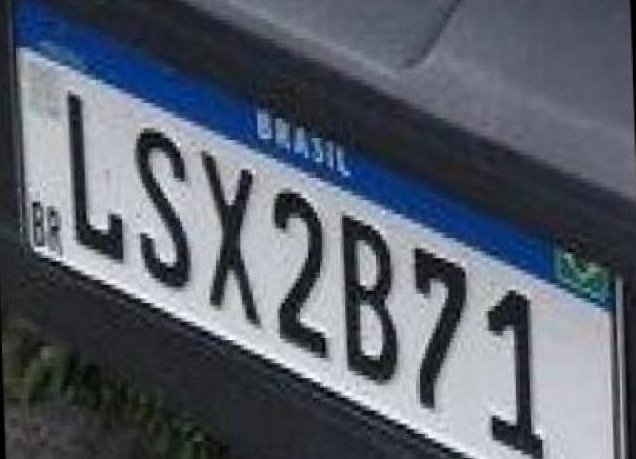


0: 480x640 1 1, 2 2s, 1 7, 1 b, 1 l, 1 x, 12.4ms
Speed: 3.1ms preprocess, 12.4ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
{'dig1': 'l', 'dig2': 'S', 'dig3': 'x', 'dig4': '2', 'dig5': 'b', 'dig6': '7', 'dig7': '1'}


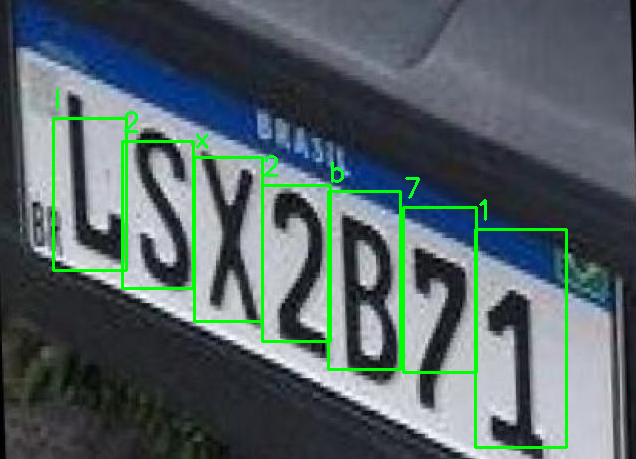

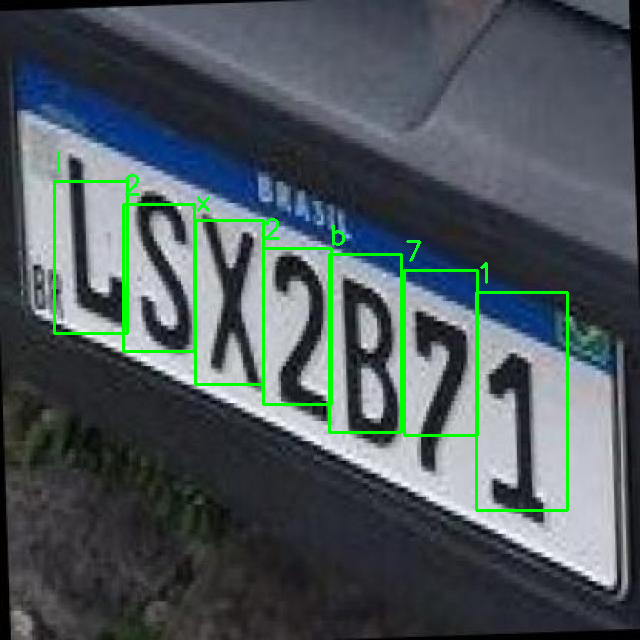

In [26]:
from google.colab.patches import cv2_imshow
from typing import Dict

def detect_plate_and_chars(image_path):
    # Carregar imagem
    image = cv2.imread(image_path)

    # Fazer a detecção da placa
    plate_results = yolo_plate(image)

    # Para cada detecção de placa
    for plate in plate_results[0].boxes:
        # Obter as coordenadas da placa detectada
        x1, y1, x2, y2 = map(int, plate.xyxy[0])

        # Recortar a região da imagem que contém a placa
        plate_region = image[y1:y2, x1:x2]

        # Mostrar a placa recortada (opcional)
        cv2_imshow(plate_region)
        cv2.waitKey(0)

        # Usar o segundo modelo YOLOv8 para detectar os caracteres dentro da placa
        char_results = yolo_char(plate_region)

        # Dicionário temporário para armazenar os caracteres da placa atual
        plate_characters = {
                    'dig1': None, 'dig2': None,
                    'dig3': None, 'dig4': None,
                    'dig5': None, 'dig6': None, 'dig7': None
                }

        if len(char_results[0].boxes) == 7:
                  # Ordenar as caixas de detecção com base na coordenada x1 (a posição mais à esquerda)
                  sorted_chars = sorted(char_results[0].boxes, key=lambda char: int(char.xyxy[0][0]))

                  # Desenhar as caixas e os textos detectados na imagem da placa
                  for idx, char in enumerate(sorted_chars):
                      cx1, cy1, cx2, cy2 = map(int, char.xyxy[0])
                      char_text = int(char.cls)  # Rótulo do caractere detectado
                      plate_characters[f'dig{idx+1}'] = str(yolo_char.names[char_text]).lower()

                      # Desenhar retângulo em volta dos caracteres e adicionar o texto (rótulo)
                      cv2.rectangle(plate_region, (cx1, cy1), (cx2, cy2), (0, 255, 0), 2)
                      cv2.putText(plate_region, str(yolo_char.names[char_text]), (cx1, cy1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36, 255, 12), 2)

        # Concatenar os caracteres da placa em uma string
        placa_detectada = ''.join(plate_characters.values())

        # Imprimir a placa como texto no vídeo (no topo do veículo)
        #cv2.putText(image, f"Placa: {placa_detectada}", (vx1, vy1 - 50),
        #                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

        # Exibir a placa com caracteres detectados (opcional)
        print(validate_plate(plate_characters, '0'))
        cv2_imshow(plate_region)
        cv2.waitKey(0)

    # Mostrar a imagem final com as placas e caracteres detectados
    cv2_imshow(image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# Exemplo de uso
detect_plate_and_chars("arquivos/copia_teste.jpg")

In [27]:
# 1 - bicycle
# 2 - car
# 3 - motorcycle
# 5 - bus
# 6 - train
# 7 - truck
import cv2

# Classes de interesse do modelo pré treinado
class_ = [1, 2, 3, 5, 6, 7]

plates_detects = []

def detect_vehicle_plate_and_chars_in_video(filename):
    cap = cv2.VideoCapture(f'arquivos/{filename}.mp4')

    # Obter as propriedades do vídeo original
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Definir o codec e criar o objeto VideoWriter para salvar o vídeo
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec para o formato de saída (MP4)
    out = cv2.VideoWriter(f'{filename}-output-video.mp4', fourcc, fps, (width, height))

    # Loop pelos frames do vídeo
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break  # Se não conseguir ler o frame, terminar

        # Fazer a detecção do veículo
        vehicle_results = yolo(frame, classes=class_, conf=0.5, iou=0.5)

        # Para cada detecção de veículo
        for vehicle in vehicle_results[0].boxes:
            # Obter as coordenadas do veículo detectado
            vx1, vy1, vx2, vy2 = map(int, vehicle.xyxy[0])

            vehicle_type = yolo.names[int(vehicle.cls)]  # Tipo do veículo detectado (carro, moto, etc.)

            # Desenhar a caixa ao redor do veículo detectado
            cv2.rectangle(frame, (vx1, vy1), (vx2, vy2), (0, 0, 255), 2)
            cv2.putText(frame, f"{vehicle_type} ({int(vehicle.conf*100)}%)",
                            (vx1, vy1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

            # Recortar a região do veículo detectado
            vehicle_region = frame[vy1:vy2, vx1:vx2]

            # Fazer a detecção da placa dentro da região do veículo (0: Padrão Mercosul)
            plate_results = yolo_plate(vehicle_region)

            # Para cada detecção de placa dentro do veículo
            for plate in plate_results[0].boxes:
                # Obter as coordenadas da placa detectada
                px1, py1, px2, py2 = map(int, plate.xyxy[0])

                class_plate = yolo_plate.names[int(plate.cls)]

                # Recortar a região da imagem que contém a placa
                plate_region = vehicle_region[py1:py2, px1:px2]

                # Desenhar a caixa ao redor da placa
                cv2.rectangle(vehicle_region, (px1, py1), (px2, py2), (0, 255, 0), 2)
                cv2.putText(vehicle_region, "Placa", (px1, py1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

                # Usar o modelo YOLOv8 para detectar os caracteres dentro da placa
                char_results = yolo_char(plate_region)

                # Dicionário temporário para armazenar os caracteres da placa atual
                plate_characters = {
                    'dig1': None, 'dig2': None,
                    'dig3': None, 'dig4': None,
                    'dig5': None, 'dig6': None,
                    'dig7': None
                }

                if len(char_results[0].boxes) == 7:
                  # Ordenar as caixas de detecção com base na coordenada x1 (a posição mais à esquerda)
                  sorted_chars = sorted(char_results[0].boxes, key=lambda char: int(char.xyxy[0][0]))

                  # Desenhar as caixas e os textos detectados na imagem da placa
                  for idx, char in enumerate(sorted_chars):
                      cx1, cy1, cx2, cy2 = map(int, char.xyxy[0])
                      char_text = int(char.cls)  # Rótulo do caractere detectado
                      plate_characters[f'dig{idx+1}'] = str(yolo_char.names[char_text]).upper()

                      # Desenhar retângulo em volta dos caracteres e adicionar o texto (rótulo)
                      cv2.rectangle(plate_region, (cx1, cy1), (cx2, cy2), (0, 255, 0), 2)
                      cv2.putText(plate_region, str(char_text), (cx1, cy1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36, 255, 12), 2)

                  plate_characters = validate_plate(plate_characters, class_plate)
                  # Concatenar os caracteres da placa em uma string
                  placa_detectada = ''.join(plate_characters.values())
                    # Imprimir a placa como texto no vídeo (no topo do veículo)
                  cv2.putText(frame, f"Placa: {placa_detectada}", (vx1, vy1 - 50),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

                  plates_detects.append(plate_characters)

        # Escrever o frame processado no novo vídeo
        out.write(frame)
        #break

    # Liberar recursos
    cap.release()
    out.release()

filename = 'camera-placa-carro'
detect_vehicle_plate_and_chars_in_video(filename)

A saída de streaming foi truncada nas últimas 5000 linhas.
0: 640x416 (no detections), 9.0ms
Speed: 2.2ms preprocess, 9.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 416)

0: 384x640 1 motorcycle, 9.5ms
Speed: 1.9ms preprocess, 9.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 640x448 (no detections), 10.6ms
Speed: 2.8ms preprocess, 10.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 448)

0: 384x640 1 motorcycle, 9.5ms
Speed: 1.8ms preprocess, 9.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 640x448 (no detections), 8.4ms
Speed: 2.0ms preprocess, 8.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 448)

0: 384x640 1 motorcycle, 9.1ms
Speed: 1.9ms preprocess, 9.1ms inference, 4.3ms postprocess per image at shape (1, 3, 384, 640)

0: 640x448 (no detections), 16.1ms
Speed: 3.2ms preprocess, 16.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 448)

0: 384x640 1 motorcycle, 9.9m